In [10]:
import os
import yaml
import cv2
import numpy as np
from pathlib import Path

##  YOLO Family Load

In [11]:
!pip install ultralytics --quiet
from ultralytics import YOLO

## Dataset copied and validation 

In [12]:
import os
from PIL import Image
import shutil


splits = ['train', 'valid', 'test']
for s in splits:
    src_img = f'/kaggle/input/set-menu-yolov9/{s}/images'
    src_lbl = f'/kaggle/input/set-menu-yolov9/{s}/labels'
    
    dst_img = f'/kaggle/working/{s}/images'
    dst_lbl = f'/kaggle/working/{s}/labels'
    
    os.makedirs(dst_img, exist_ok=True)
    os.makedirs(dst_lbl, exist_ok=True)
    
    # Copy and validate images
    for f in os.listdir(src_img):
        src_path = os.path.join(src_img, f)
        try:
            Image.open(src_path).verify()  # check image validity
            shutil.copy(src_path, dst_img)
        except:
            print(f"Skipping invalid image: {f}")
    
    # Copy label files
    for f in os.listdir(src_lbl):
        shutil.copy(os.path.join(src_lbl, f), dst_lbl)

print("Dataset copied and validated ✅")


Dataset copied and validated ✅


# Load YAML

In [15]:
yaml_content = """
train: /kaggle/working/train/images
val:   /kaggle/working/valid/images
test:  /kaggle/working/test/images

nc: 10
names: ['Beef', 'Biryani', 'Chicken', 'Chingri', 'Dal', 'Egg Curry', 'Fish Curry', 'Khichuri', 'Parota', 'Rice']
"""

with open("/kaggle/working/data.yaml", "w") as f:
    f.write(yaml_content)

print("✅ data.yaml saved successfully and ready for YOLOv8 training!")

✅ data.yaml saved successfully and ready for YOLOv8 training!


# Filter Segmentation Dataset

In [ ]:
import os, shutil

def filter_segmentation_dataset(labels_dir, images_dir, output_labels_dir, output_images_dir):
    """Keep only images with polygon (segmentation) annotations — YOLO format"""
    
    os.makedirs(output_labels_dir, exist_ok=True)
    os.makedirs(output_images_dir, exist_ok=True)
    
    bbox_count = 0
    polygon_count = 0
    
    for label_file in os.listdir(labels_dir):
        if not label_file.endswith('.txt'):
            continue
            
        label_path = os.path.join(labels_dir, label_file)
        has_polygon = False
        
        with open(label_path, 'r') as f:
            for line in f:
                coords = line.strip().split()
                num_coords = len(coords) - 1  # exclude class_id
                # YOLO segmentation polygons have more than 4 coordinates
                if num_coords > 4:
                    has_polygon = True
                    break
        
        if has_polygon:
            polygon_count += 1
            shutil.copy(label_path, os.path.join(output_labels_dir, label_file))
            image_name = label_file.replace('.txt', '')
            for ext in ['.jpg', '.jpeg', '.png', '.JPG', '.JPEG', '.PNG']:
                img_path = os.path.join(images_dir, image_name + ext)
                if os.path.exists(img_path):
                    shutil.copy(img_path, os.path.join(output_images_dir, image_name + ext))
                    break
        else:
            bbox_count += 1
    
    print(f"✅ Kept (segmentation polygon) images: {polygon_count}")
    print(f"🚫 Skipped (bounding box only) images: {bbox_count}")


# Paths
train_labels = '/kaggle/working/train/labels'
train_images = '/kaggle/working/train/images'
valid_labels = '/kaggle/working/valid/labels'
valid_images = '/kaggle/working/valid/images'

# Run the filter
filter_segmentation_dataset(train_labels, train_images,
                            '/kaggle/working/train_filtered/labels',
                            '/kaggle/working/train_filtered/images')

filter_segmentation_dataset(valid_labels, valid_images,
                            '/kaggle/working/valid_filtered/labels',
                            '/kaggle/working/valid_filtered/images')


In [17]:
yaml_seg_content = """
train: /kaggle/working/train_filtered/images
val: /kaggle/working/valid_filtered/images

nc: 10
names: ['Beef', 'Biryani', 'Chicken', 'Chingri', 'Dal', 'Egg Curry', 'Fish Curry', 'Khichuri', 'Parota', 'Rice']
"""

with open("/kaggle/working/data_seg.yaml", "w") as f:
    f.write(yaml_seg_content)

print("✅ data_seg.yaml saved successfully for segmentation training!")


✅ data_seg.yaml saved successfully for segmentation training!


# YOLOV8N

In [18]:
from ultralytics import YOLO

model = YOLO("yolov8n-seg.pt")
model.train(
    data="/kaggle/working/data_seg.yaml",
    epochs=50,
    imgsz=640,
    batch=16
)


Ultralytics 8.3.241 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/data_seg.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=True, 

/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1
/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


                   all         88        189      0.752      0.671      0.752      0.574      0.752      0.671      0.752      0.558
                  Beef         17         18      0.462      0.383      0.502      0.345      0.462      0.383      0.513      0.325
               Biryani          6          7      0.872      0.978      0.978      0.668      0.872      0.978      0.978      0.622
               Chicken         25         27      0.636      0.325      0.518      0.359      0.636      0.325      0.498      0.335
               Chingri          5          5      0.443        0.4      0.563      0.496      0.443        0.4      0.563      0.486
                   Dal         18         19      0.927      0.789      0.914      0.754      0.927      0.789       0.92      0.699
             Egg Curry         20         23      0.771      0.565      0.649      0.471      0.771      0.565      0.649       0.48
            Fish Curry         14         16      0.695      0.625   

ultralytics.utils.metrics.SegmentMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7fdd885d6b50>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)', 'Precision-Recall(M)', 'F1-Confidence(M)', 'Precision-Confidence(M)', 'Recall-Confidence(M)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,

In [36]:
yolo = model

In [35]:
import torch
import cv2
import numpy as np
import matplotlib.pyplot as plt


In [200]:
midas = torch.hub.load("intel-isl/MiDaS", "MiDaS_small")
midas.eval()

midas_transforms = torch.hub.load("intel-isl/MiDaS", "transforms")
transform = midas_transforms.small_transform

print("MiDaS loaded")


Using cache found in /root/.cache/torch/hub/intel-isl_MiDaS_master


Loading weights:  None


Using cache found in /root/.cache/torch/hub/rwightman_gen-efficientnet-pytorch_master


MiDaS loaded


Using cache found in /root/.cache/torch/hub/intel-isl_MiDaS_master


(-0.5, 1178.5, 1277.5, -0.5)

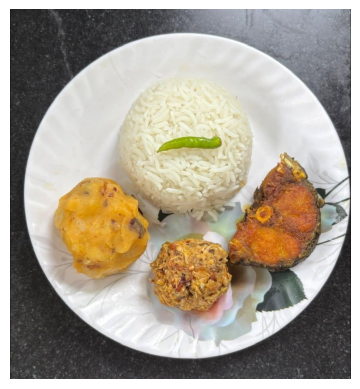

In [243]:

image_path = "/kaggle/working/test/images/a9f8934c9cae7d798a417e68be4a17ea_jpg.rf.23ac336e64d455baa5f9b2f67c8e5c59.jpg"
img = cv2.imread(image_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img_rgb)
plt.axis("off")


In [244]:
results = yolo(img)[0]

masks = results.masks.data.cpu().numpy()   # (N, H, W)
classes = results.boxes.cls.cpu().numpy().astype(int)
names = results.names

print("Detected food items:")
for c in classes:
    print(names[c])



0: 640x608 1 Fish Curry, 1 Rice, 45.9ms
Speed: 3.9ms preprocess, 45.9ms inference, 2.0ms postprocess per image at shape (1, 3, 640, 608)
Detected food items:
Rice
Fish Curry


(-0.5, 1178.5, 1277.5, -0.5)

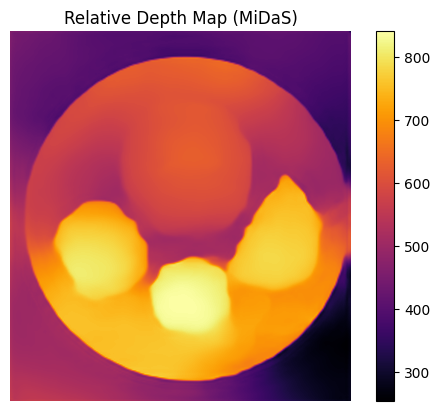

In [245]:
# MiDaS expects input shape: [B, 3, H, W]
input_batch = transform(img)

with torch.no_grad():
    depth = midas(input_batch)

# Resize depth map to image resolution
depth = torch.nn.functional.interpolate(
    depth.unsqueeze(1),
    size=img.shape[:2],
    mode="bicubic",
    align_corners=False
).squeeze()

depth_map = depth.cpu().numpy()

plt.imshow(depth_map, cmap="inferno")
plt.colorbar()
plt.title("Relative Depth Map (MiDaS)")
plt.axis("off")


In [227]:
print("Input batch shape:", input_batch.shape)
print("Depth output shape:", depth.shape)

Input batch shape: torch.Size([1, 3, 256, 160])
Depth output shape: torch.Size([1083, 735])


In [246]:
# Ensure depth map matches YOLO mask resolution
mask_h, mask_w = masks[0].shape
depth_map_resized = cv2.resize(
    depth_map,
    (mask_w, mask_h),
    interpolation=cv2.INTER_CUBIC
)


In [247]:
# Example calibration factors kc (per food class)
calibration_factors = {
    "rice": 0.0000021,
    "dal": 0.0019,
    "chicken": 0.0023,
    "beef": 0.0000024,
    "fish": 0.0020,
    "egg curry": 0.0021,
    "khichuri": 0.0022,
    "parota": 0.0028,
    "biryani": 0.0025
}

# Calories per gram
calories_per_gram = {
    "rice": 1.30,
    "dal": 1.20,
    "chicken": 1.60,
    "beef": 2.50,
    "fish": 1.50,
    "egg curry": 1.80,
    "khichuri": 1.35,
    "parota": 3.00,
    "biryani": 2.00
}

In [248]:
def compute_relative_volume(mask, depth_map):
    mask = mask.astype(bool)          # ensure boolean
    area = mask.sum()                 # Ai

    if area == 0:
        return 0, 0, 0

    mean_depth = depth_map[mask].mean()
    volume = area * mean_depth

    return area, mean_depth, volume


In [253]:
results = yolo(img_rgb, imgsz=640, conf=0.2, iou=0.3)
r = results[0]
masks = r.masks.data.cpu().numpy()
classes = r.boxes.cls.cpu().numpy().astype(int)



0: 640x608 1 Rice, 12.0ms
Speed: 4.1ms preprocess, 12.0ms inference, 2.4ms postprocess per image at shape (1, 3, 640, 608)


In [254]:
mask_bool = (mask > 0.5)   # threshold mask
area = mask_bool.sum()
mean_depth = depth_map_resized[mask_bool].mean()
volume = area * mean_depth

In [255]:
plate_diameter_cm = 25
img_size = 640  # YOLO input size
plate_area_pixels = np.pi * (img_size / 2)**2  # pixels inside plate

# Real plate area in cm^2
plate_area_cm2 = np.pi * (plate_diameter_cm / 2)**2

# Scaling factor
pixel_to_cm2 = plate_area_cm2 / plate_area_pixels
area_cm2 = area * pixel_to_cm2


In [256]:
total_calories = 0
plate_diameter_cm = 25
img_size = 640
plate_area_pixels = np.pi * (img_size / 2)**2
plate_area_cm2 = np.pi * (plate_diameter_cm / 2)**2
pixel_to_cm2 = plate_area_cm2 / plate_area_pixels

for i, mask in enumerate(masks):
    food_name = names[classes[i]].lower()
    if food_name not in calibration_factors:
        continue

    mask_bool = (mask > 0.5)
    area = mask_bool.sum()
    mean_depth = depth_map_resized[mask_bool].mean()

    # Convert pixel area to cm^2
    area_cm2 = area * pixel_to_cm2

    # Relative volume
    volume = area_cm2 * mean_depth

    # Weight and calories
    weight = calibration_factors[food_name] * volume
    calories = weight * calories_per_gram[food_name]
    total_calories += calories

    print(f"\nFood: {food_name}")
    print(f"Area (cm^2): {area_cm2:.1f}")
    print(f"MeanDepth: {mean_depth:.4f}")
    print(f"Volume: {volume:.2f}")
    print(f"Weight: {weight:.2f} g")
    print(f"Calories: {calories:.2f} kcal")

print(f"\nTotal Meal Calories: {total_calories:.2f} kcal")



Food: rice
Area (cm^2): 82.9
MeanDepth: 588.0985
Volume: 48762.93
Weight: 0.10 g
Calories: 0.13 kcal

Total Meal Calories: 0.13 kcal


In [258]:
total_calories = 0

for i, mask in enumerate(masks):
    food_name = names[classes[i]].lower()
    print(food_name)

    if food_name not in calibration_factors:
        continue

    # Threshold mask
    mask_bool = (mask > 0.5)

    # Compute volume safely
    area = mask_bool.sum()
    mean_depth = depth_map_resized[mask_bool].mean()
    volume = area * mean_depth

    # Convert to weight & calories
    weight = calibration_factors[food_name] * volume
    calories = weight * calories_per_gram[food_name]

    total_calories += calories

    print(f"\nFood: {food_name}")
    print(f"Area: {area}")
    print(f"MeanDepth: {mean_depth:.4f}")
    print(f"Weight: {weight:.2f} g")
    print(f"Calories: {calories:.2f} kcal")

print(f"\nTotal Meal Calories: {total_calories:.2f} kcal")


rice

Food: rice
Area: 54340
MeanDepth: 588.0985
Weight: 67.11 g
Calories: 87.24 kcal

Total Meal Calories: 87.24 kcal


In [97]:
for i, mask in enumerate(masks):
    food_name = names[classes[i]].lower()

    if food_name not in calibration_factors:
        continue

    area, mean_depth, volume = compute_relative_volume(
        mask,
        depth_map_resized
    )

    weight = calibration_factors[food_name] * volume
    calories = weight * calories_per_gram[food_name]

    print(f"\nFood: {food_name}")
    print(f"Area: {area}")
    print(f"MeanDepth: {mean_depth:.4f}")
    print(f"Weight: {weight:.2f} g")
    print(f"Calories: {calories:.2f} kcal")



Food: rice
Area: 118614
MeanDepth: 556.2542
Weight: 138557.01 g
Calories: 180124.12 kcal


In [ ]:
total_calories = 0

for i, mask in enumerate(masks):
    food_name = names[classes[i]].lower()

    if food_name not in calibration_factors:
        continue

    area, mean_depth, volume = compute_relative_volume(mask, depth_map)

    weight = calibration_factors[food_name] * volume
    calories = weight * calories_per_gram[food_name]

    total_calories += calories

    print(f"\nFood: {food_name}")
    print(f"Area (Ai): {area:.0f}")
    print(f"MeanDepth: {mean_depth:.3f}")
    print(f"Relative Volume: {volume:.2f}")
    print(f"Estimated Weight: {weight:.1f} g")
    print(f"Calories: {calories:.1f} kcal")

print(f"\n🔥 Total Estimated Calories: {total_calories:.1f} kcal")


In [79]:
def compute_relative_volume(mask, depth_map):
    area = mask.sum()  # Ai
    mean_depth = depth_map[mask == 1].mean()  # MeanDepth_i
    volume = area * mean_depth
    return area, mean_depth, volume

# Starting newly

In [87]:
results = yolo(img, imgsz=640, conf=0.25)

r = results[0]
masks = r.masks.data.cpu().numpy()        # (N, 640, 640)
classes = r.boxes.cls.cpu().numpy().astype(int)
names = r.names



0: 640x640 1 Egg Curry, 1 Rice, 11.2ms
Speed: 4.3ms preprocess, 11.2ms inference, 2.6ms postprocess per image at shape (1, 3, 640, 640)


In [ ]:
input_batch = transform(img_rgb).to(device)

with torch.no_grad():
    depth = midas(input_batch)

depth = torch.nn.functional.interpolate(
    depth.unsqueeze(1),
    size=img_rgb.shape[:2],
    mode="bicubic",
    align_corners=False
).squeeze()

depth_map = depth.cpu().numpy()


In [61]:
img_path = "/kaggle/working/test/images/3064813c814fb175dc948acecc1d16f7_jpg.rf.cf12f5288f22bdf75b60c598ab3dee73.jpg"
img = cv2.imread(img_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
H, W = img_rgb.shape[:2]
image_path = "/kaggle/working/test/images/3064813c814fb175dc948acecc1d16f7_jpg.rf.cf12f5288f22bdf75b60c598ab3dee73.jpg"
image = cv2.imread(image_path)



In [62]:
results = results = model(image)[0]

if results.masks is None:
    print("No food detected.")
    masks = []
    classes = []
    names = results.names
else:
    masks = results.masks.data.cpu().numpy()   # (N, H, W)
    classes = results.boxes.cls.cpu().numpy().astype(int)
    names = results.names



0: 640x640 1 Egg Curry, 1 Rice, 10.2ms
Speed: 3.7ms preprocess, 10.2ms inference, 2.2ms postprocess per image at shape (1, 3, 640, 640)


In [63]:
results = yolo(image, conf=0.25)[0]
masks = results.masks.data.cpu().numpy()  # (N, H, W)
classes = results.boxes.cls.cpu().numpy().astype(int)
names = results.names



0: 640x640 1 Egg Curry, 1 Rice, 9.6ms
Speed: 3.4ms preprocess, 9.6ms inference, 2.1ms postprocess per image at shape (1, 3, 640, 640)


In [67]:
input_batch = transform(img).to(device)

with torch.no_grad():
    depth_pred = midas(input_batch)
    depth_pred = torch.nn.functional.interpolate(
        depth_pred.unsqueeze(1),
        size=(H, W),
        mode="bicubic",
        align_corners=False
    ).squeeze()

depth_map = depth_pred.cpu().numpy()


In [68]:
def compute_volume(mask, depth_map):
    """
    mask: (H, W) boolean
    depth_map: (H, W) float
    """
    mask = mask.astype(bool)
    area = mask.sum()  # A_i

    if area == 0:
        return 0.0, 0.0

    mean_depth = depth_map[mask].mean()   # MeanDepth_i
    volume = area * mean_depth            # V_i

    return mean_depth, volume


In [69]:
alpha_dict = {
    "Rice": 0.0020,
    "Dal": 0.0023,
    "Chicken Curry": 0.0026,
    "Beef Curry": 0.0028,
    "Fish Curry": 0.0024,
    "Egg Curry": 0.0025,
    "Chingri (Prawn)": 0.0027,
    "Khichuri": 0.0021,
    "Parota": 0.0030,
    "Biryani": 0.0022
}


In [ ]:
food_stats = []
total_volume = 0.0
total_weight = 0.0

for i, mask in enumerate(masks):
    cls_id = classes[i]
    cls_name = names[cls_id]

    mean_d, vol = compute_volume(mask, depth_map)

    alpha = alpha_dict.get(cls_name, 0.002)  # fallback
    weight = alpha * vol

    food_stats.append({
        "food": cls_name,
        "area_px": int(mask.sum()),
        "mean_depth": float(mean_d),
        "volume": float(vol),
        "weight_g": float(weight)
    })

    total_volume += vol
    total_weight += weight


In [64]:
def compute_volume(mask, depth_map):
    """
    mask: binary (H, W)
    depth_map: (H, W)
    """
    area = np.sum(mask)  # A_i
    if area == 0:
        return 0, 0

    mean_depth = depth_map[mask].mean()  # MeanDepth_i
    volume = area * mean_depth           # V_i

    return mean_depth, volume


In [66]:
food_stats = []

for i in range(len(masks)):
    mask = masks[i] > 0.5
    cls_name = names[classes[i]]

    mean_d, vol = compute_volume(mask, depth_map)

    food_stats.append({
        "food": cls_name,
        "area": int(mask.sum()),
        "mean_depth": float(mean_d),
        "volume": float(vol)
    })


IndexError: boolean index did not match indexed array along dimension 0; dimension is 1440 but corresponding boolean dimension is 640

In [ ]:
for f in food_stats:
    print(
        f"{f['food']} | "
        f"Area: {f['area']} px | "
        f"MeanDepth: {f['mean_depth']:.2f} | "
        f"Relative Volume: {f['volume']:.2f}"
    )


In [ ]:
alpha = {
    "Rice": 0.0020,
    "Fish Curry": 0.0024,
    "Beef Curry": 0.0028
}

for f in food_stats:
    if f["food"] in alpha:
        weight = alpha[f["food"]] * f["volume"]
        print(f"{f['food']} → Estimated Weight: {weight:.1f} g")


In [ ]:
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"

# Load MiDaS model
midas = torch.hub.load("intel-isl/MiDaS", "DPT_Hybrid")
midas.to(device)
midas.eval()

# Load transforms
midas_transforms = torch.hub.load("intel-isl/MiDaS", "transforms")
transform = midas_transforms.dpt_transform

print("MiDaS loaded on", device)


In [ ]:
import cv2
import torch
from IPython.display import display
import ipywidgets as widgets


In [ ]:
midas = torch.hub.load("intel-isl/MiDaS", "MiDaS_small")
midas.eval()
transform = torch.hub.load("intel-isl/MiDaS", "transforms").small_transform

In [10]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [59]:
def compute_food_volume(mask, depth_map):
    # mask: binary mask (H x W)
    return np.sum(depth_map[mask > 0])


In [ ]:
# Run segmentation
results = model(image)[0]

# Target shape from YOLO masks
mask_h, mask_w = results.masks.data.shape[-2:]

# Run depth estimation resized to mask size
depth_map = estimate_depth(image, (mask_h, mask_w))


In [ ]:
image_path = "/kaggle/working/test/images/3064813c814fb175dc948acecc1d16f7_jpg.rf.cf12f5288f22bdf75b60c598ab3dee73.jpg"
image = cv2.imread(image_path)

# Run segmentation
results = model(image)[0]

# Target shape from YOLO masks
mask_h, mask_w = results.masks.data.shape[-2:]

# Run depth estimation resized to mask size
depth_map = estimate_depth(image, (mask_h, mask_w))


total_volume = 0
food_volumes = []

for i, mask in enumerate(results.masks.data):
    mask_np = mask.cpu().numpy()
    volume = compute_food_volume(mask_np, depth_map)
    food_volumes.append(volume)
    total_volume += volume

In [ ]:
print("Depth shape:", depth_map.shape)
print("Mask shape:", results.masks.data[0].shape)


In [ ]:
volume = compute_food_volume(mask_np, depth_map)
volume

In [32]:
depth_map = depth_map.astype("float32")
depth_map = (depth_map - depth_map.min()) / (depth_map.max() - depth_map.min() + 1e-8)

In [33]:
food_depth_info = []

for i, mask in enumerate(results.masks.data):
    cls_id = int(results.boxes.cls[i])
    food_name = model.names[cls_id]

    mask_np = mask.cpu().numpy().astype(bool)

    # Extract depth pixels for this food
    depth_pixels = depth_map[mask_np]

    mean_depth = depth_pixels.mean()
    max_depth = depth_pixels.max()
    min_depth = depth_pixels.min()

    volume = depth_pixels.sum()  # depth-based volume proxy

    food_depth_info.append({
        "food": food_name,
        "mean_depth": mean_depth,
        "max_depth": max_depth,
        "min_depth": min_depth,
        "volume": volume
    })

    print(
        f"{food_name} | "
        f"mean depth: {mean_depth:.4f}, "
        f"max depth: {max_depth:.4f}, "
        f"volume: {volume:.2f}"
    )


Egg Curry | mean depth: 0.6811, max depth: 1.0000, volume: 94176.59
Rice | mean depth: 0.6640, max depth: 0.8992, volume: 78764.34


# YOLOV8X

In [ ]:
from ultralytics import YOLO

model = YOLO("yolov8m-seg.pt")
model.train(
    data="/kaggle/working/data_seg.yaml",
    epochs=100,
    imgsz=640,
    batch=16
)


# YOLOV9C-SEG

In [ ]:
from ultralytics import YOLO

model = YOLO("yolov9c-seg.pt")
model.train(
    data="/kaggle/working/data_seg.yaml",
    epochs=100,
    imgsz=640,
    batch=16
)


# YOLOV9E- SEG

In [ ]:
from ultralytics import YOLO

model = YOLO("yolov9e-seg.pt")
model.train(
    data="/kaggle/working/data_seg.yaml",
    epochs=100,
    imgsz=640,
    batch=16
)


# YOLOV11n

In [ ]:
from ultralytics import YOLO

model = YOLO("yolo11n-seg.pt")
model.train(
    data="/kaggle/working/data_seg.yaml",
    epochs=100,
    imgsz=640,
    batch=16
)


# YOLO11x

In [ ]:
from ultralytics import YOLO

model = YOLO("yolo11x-seg.pt")
model.train(
    data="/kaggle/working/data_seg.yaml",
    epochs=100,
    imgsz=640,
    batch=16
)


# YOLOV8X

In [ ]:
from ultralytics import YOLO

model = YOLO("yolov8x-seg.pt")  # segmentation model
model.train(
    data="/kaggle/working/data_seg.yaml",
    epochs=50,
    imgsz=640,
    batch=16
)


In [ ]:
img_path = "/kaggle/working/runs/segment/val/confusion_matrix.png"

img = mpimg.imread(img_path)
plt.figure(figsize=(8, 8))
plt.imshow(img)
plt.axis('off')
plt.title("YOLOv8 Segmentation Confusion Matrix", fontsize=14)
plt.show()